# Create TPM data
June 17, 2025

**Goals:**
Load the genic and nongenic dataset and RNA seq data. Create TPM data set from the combined transcripts datasets for each replicate and sample.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from src.transcripts_dataset import load_transcripts_sets

output_dir = 'output/draft4_run/'

combined_gene_nongenic = load_transcripts_sets(output_dir, combined=True)
combined_gene_nongenic.head()

In [34]:
from src.tpm_calculator import TPMGenerator
output_dir = 'output/draft4_run/'

tpm_generator = TPMGenerator(combined_gene_nongenic, output_dir)


In [41]:
from src.read_bam import get_rna_seq_filepaths_df
bam_df = get_rna_seq_filepaths_df()

tpm_generator.process_multiple_replicates(
    bam_df, chroms=[1])



=== Processing Replicate 1 ===
Reading BAM file for time 0 minutes
1..Done. 00:00:05.584
Reading BAM file for time 10 minutes
1..Done. 00:00:11.555
Reading BAM file for time 20 minutes
1..Done. 00:00:17.800
Reading BAM file for time 30 minutes
1..Done. 00:00:23.362
Reading BAM file for time 40 minutes
1..Done. 00:00:28.928
Reading BAM file for time 50 minutes
1..Done. 00:00:34.587
Reading BAM file for time 60 minutes
1..Done. 00:00:40.073
Reading BAM file for time 70 minutes
1..Done. 00:00:45.568
Reading BAM file for time 80 minutes
1..Done. 00:00:51.053
Reading BAM file for time 90 minutes
1..Done. 00:00:56.490
Reading BAM file for time 100 minutes
1..Done. 00:01:02.126
Reading BAM file for time 110 minutes
1..Done. 00:01:08.439
Reading BAM file for time 120 minutes
1..Done. 00:01:13.735
Reading BAM file for time 130 minutes
1..Done. 00:01:19.511
Reading BAM file for time 140 minutes
1..Done. 00:01:25.347
Reading BAM file for time 150 minutes
1..Done. 00:01:31.160
Saved results for r

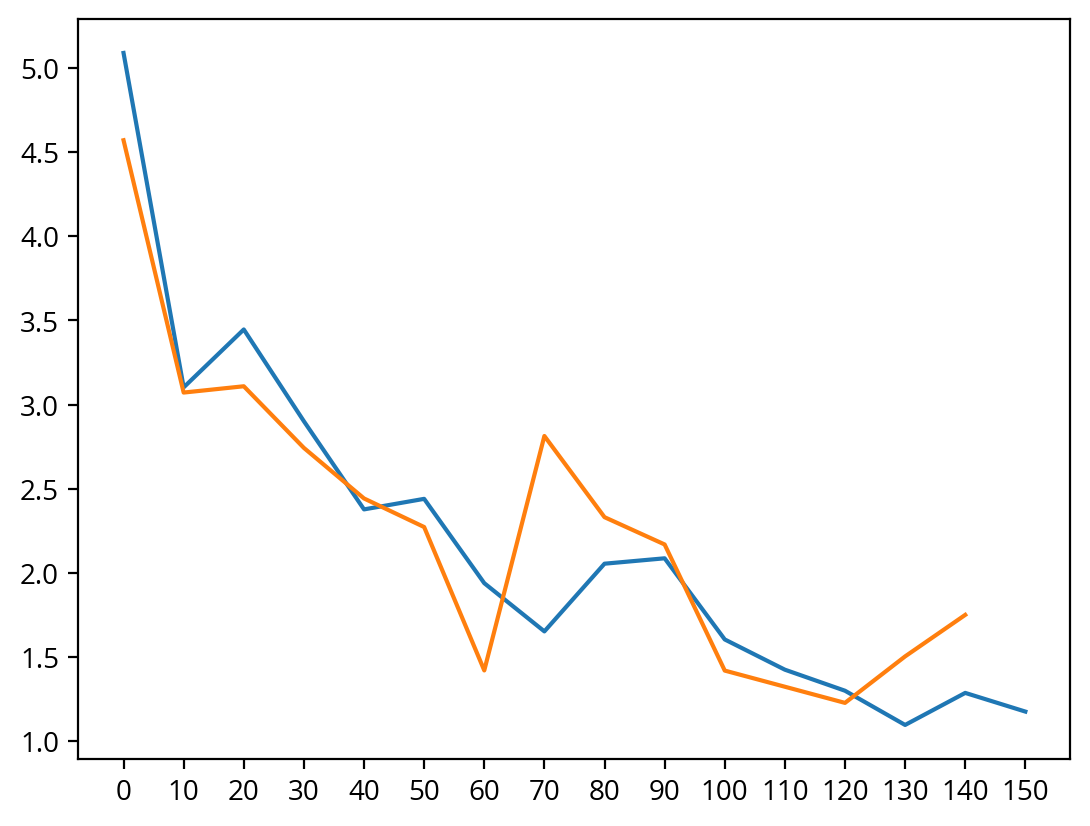

In [93]:
from src.gene_expression import load_transcription_for_name


expression_rep1 = load_transcription_for_name('nogene_chr16_775917_776355', 1)
expression_rep2 = load_transcription_for_name('nogene_chr16_775917_776355', 2)

plt.plot(expression_rep1)
plt.plot(expression_rep2)

In [106]:
from src.transcripts_dataset import load_transcripts_sets

combined_transcripts_set = load_transcripts_sets(output_dir, combined=True)
combined_transcripts_set

,chr,strand,start,stop,length
YAL068C,1,-,1807,2169,362
YAL067W-A,1,+,2480,2707,227
YAL067C,1,-,7235,9016,1781
YAL065C,1,-,11565,11951,386
YAL064W-B,1,+,12046,12426,380
...,...,...,...,...,...
nogene_chr16_883764_884048,16,-,883764,884048,285
nogene_chr16_900044_900421,16,-,900044,900421,378
nogene_chr16_930038_930990,16,-,930038,930990,953
nogene_chr16_937119_939102,16,+,937119,939102,1984


In [94]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner

tx_deconv_runner = CombinedDeconvolveGeneExpressionRunner(output_dir)

In [99]:
tx_deconv_runner.deconvolve_transcript_optimal_gamma('nogene_chr16_775917_776355',
    kappa=0.001, eta=0.264)


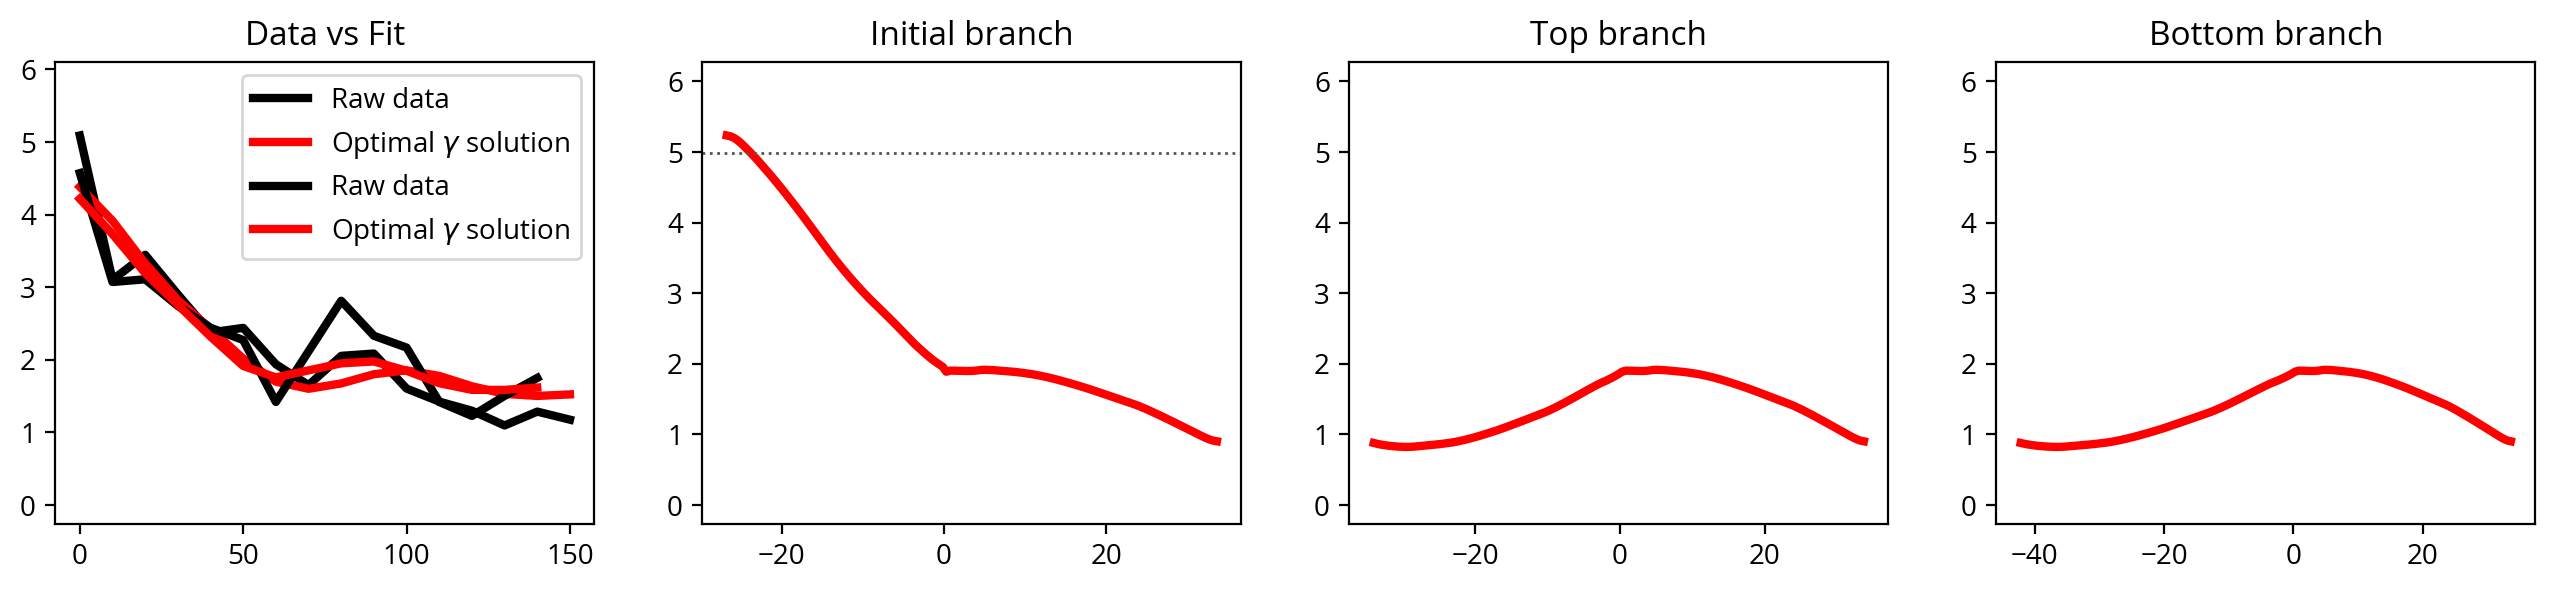

In [100]:
tx_deconv_runner.plot_solution()

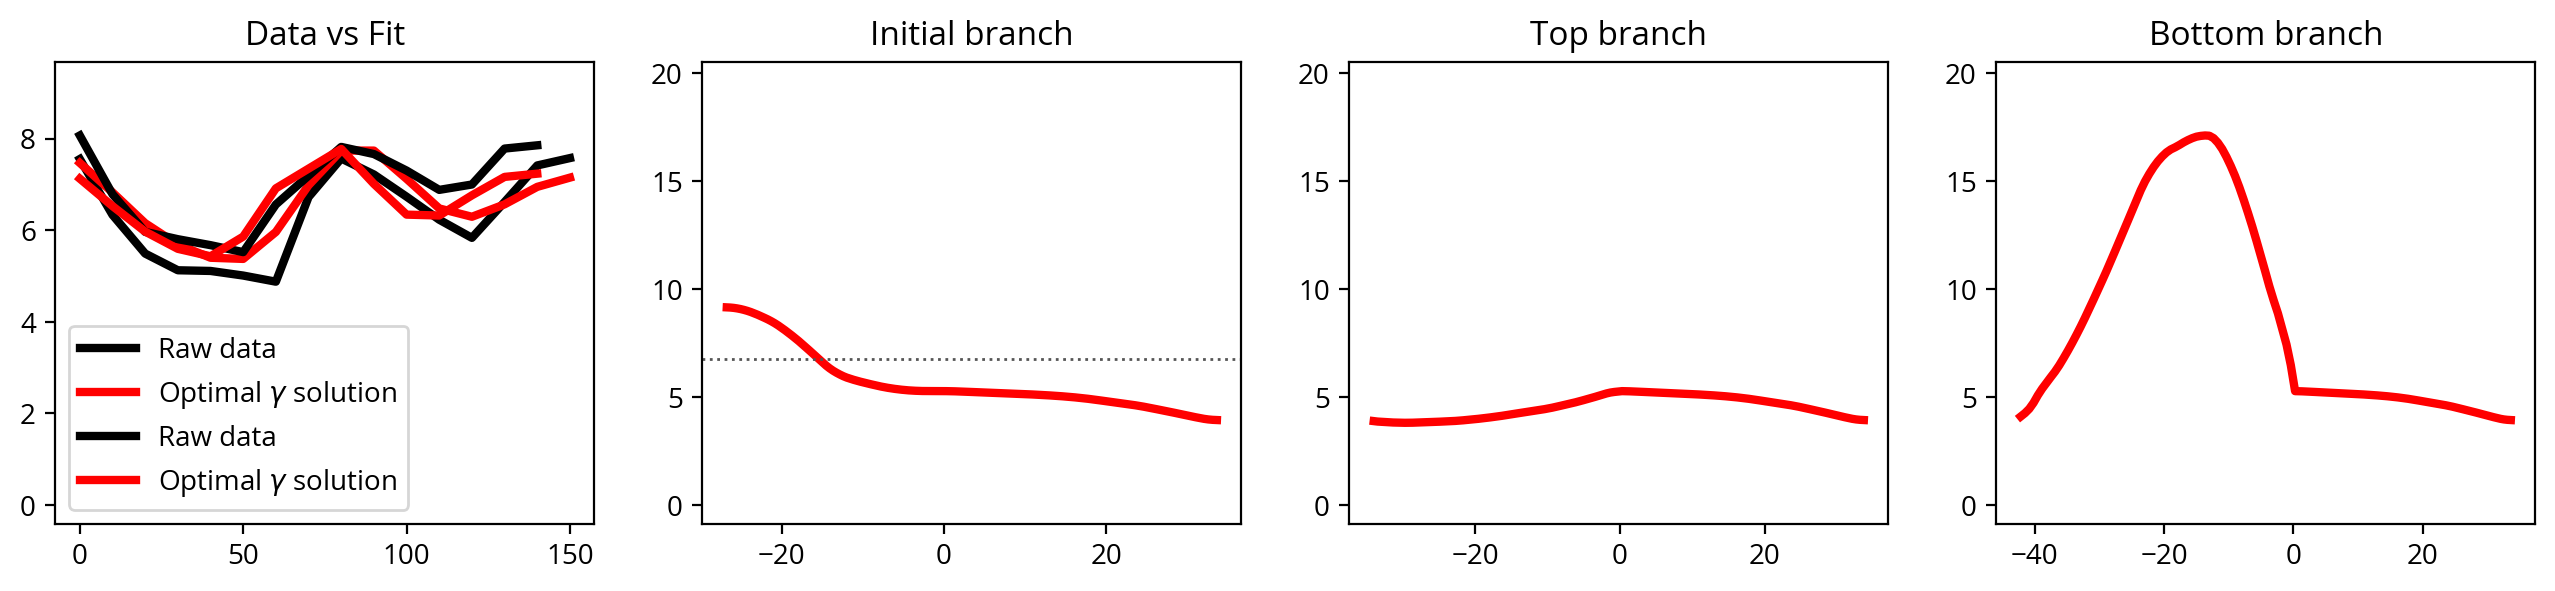

In [104]:
tx_deconv_runner.deconvolve_gene_optimal_gamma('DSE1',
    kappa=0.001, eta=0.264)
tx_deconv_runner.plot_solution()

<Axes: >

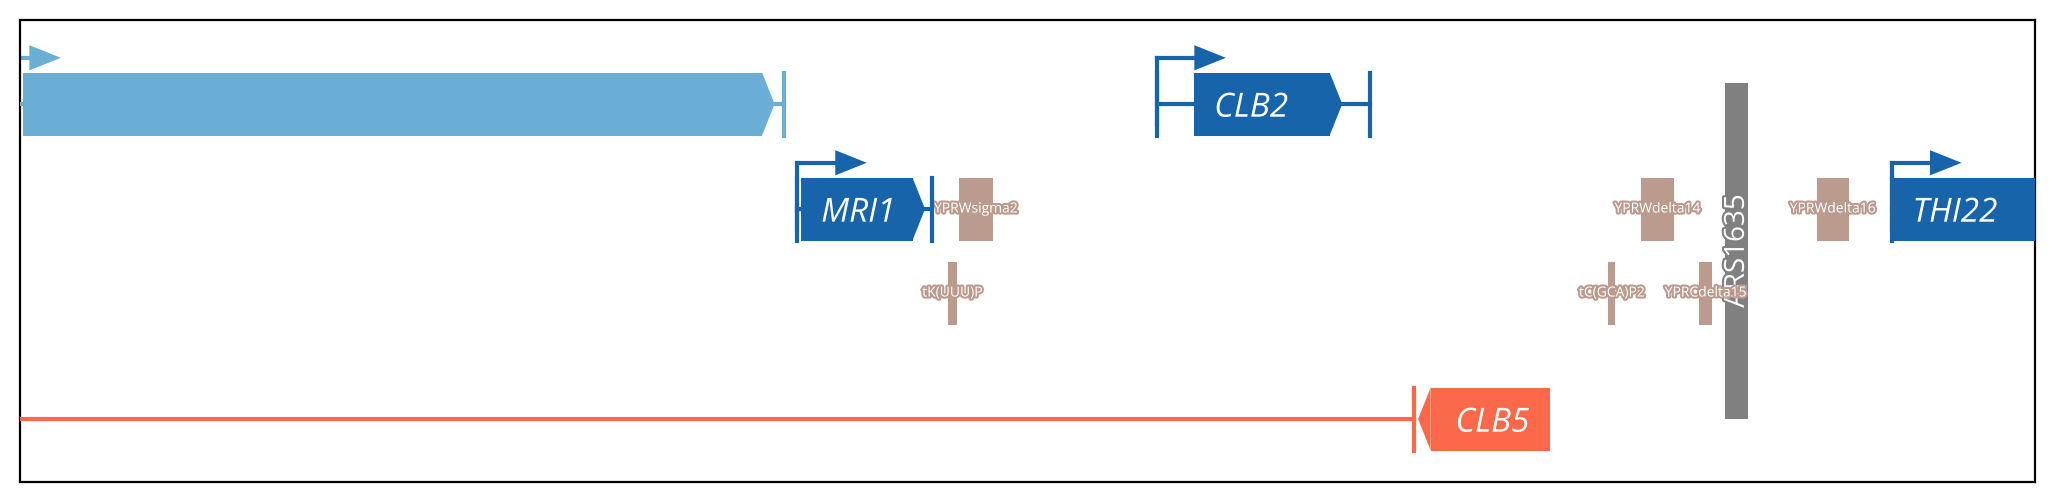

In [118]:
plt.figure(figsize=(13, 3))
orf_plotter.plot_orf_annotations(plt.gca())

In [137]:
from src.transcripts_dataset import load_transcripts_sets
txs = load_transcripts_sets('output/draft4_run/', combined=True)

In [163]:
# Load deconvolved gene expression
from src.deconv_data import load_gene_expression_fs, load_nongene_transcription_fs

outdir = 'output/draft4_run/'
gene_expression_dir = f"{outdir}genes_deconvolution/"
gene_expression_f = load_gene_expression_fs(gene_expression_dir)

In [169]:
from src.deconv_data import load_gene_expression_fs, load_nongene_transcription_fs

nongenic_f = load_nongene_transcription_fs(outdir)

0

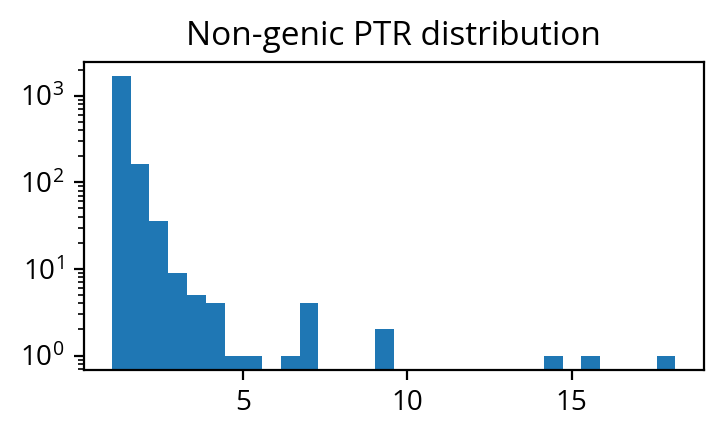

In [462]:
from src.peak_to_trough import compute_quantile_ptr_2d

nongenic_ptr = compute_quantile_ptr_2d(nongenic_f, eps=0.1)
nongenic_ptr_df = pd.DataFrame(nongenic_ptr, index=nongenic_f.index, columns=['ptr'])

plt.figure(figsize=(4, 2))
plt.hist(nongenic_ptr, bins=30)
plt.title("Non-genic PTR distribution")
plt.yscale('log')
0

In [463]:
from src.plot_helpers import plot_deconvolution_solution
from src.config import load_default_chrom_configs
from src.global_config import GlobalConstants

config1, config2 = load_default_chrom_configs()
    
def plot_nongenic_deconv_curves(index, nongenic_f, name):
    tps1 = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
    tps2 = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS
    F = nongenic_f.loc[name].values
    plot_deconvolution_solution(None, F, config1, tps1, tps2, plots=['i', 't', 'b'],
                               figsize=(7, 2), ylims=(-0.1, 12))
    plt.suptitle(f"{i}: {name}", fontweight='demi')
    plt.tight_layout()

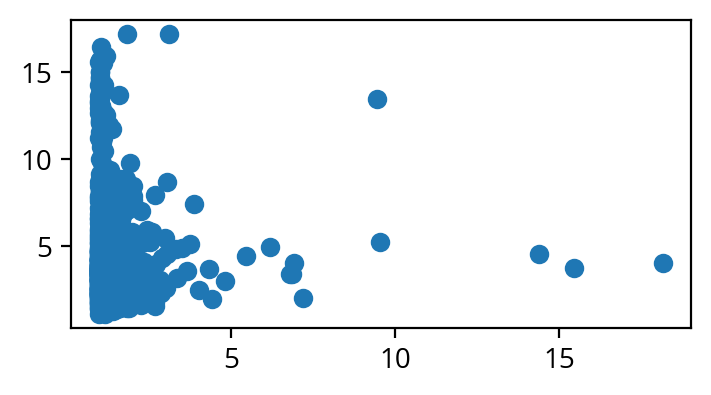

In [464]:
comparison_max_and_ptr = nongenic_ptr_df.copy()
comparison_max_and_ptr['max'] = nongenic_f[:-2].max(1)
plt.figure(figsize=(4, 2))
plt.scatter(comparison_max_and_ptr['ptr'], comparison_max_and_ptr['max'])

In [496]:
interesting_transcripts = nongenic_ptr_df.sort_values('ptr', ascending=False).head(20)

for i, tx_name in enumerate(interesting_transcripts.index.values):
    plot_nongenic_deconv_curves(i, nongenic_f, tx_name)
    plt.savefig(f'output/draft4_run/nongenic_analysis/curves_{i}_{tx_name}.png', dpi=200)
    plt.close()

/var/folders/09/f2kb1zq9485dc8jvk0sbkbcr0000gn/T/ipykernel_39627/738879669.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


In [497]:

from src.rna_pileup_plotter import RNASeqPileupPlotter
from src.orf_plotter import load_default_orf_plotter
from src.combined_chromatin_model import CombinedChromatinModel

orf_plotter = load_default_orf_plotter()
rna_plotter = RNASeqPileupPlotter(outdir)
combined_model = CombinedChromatinModel(config1=config1, config2=config2)    

Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 11
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr11.h5, crick_rna_seq_pileup_rep1_chr11.h5
Shape: (16, 666816) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr11.h5, crick_rna_seq_pileup_rep2_chr11.h5
Shape: (14, 666816) (timepoints x positions)
Already loaded chromosome reads for 11. Using cache.
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribu

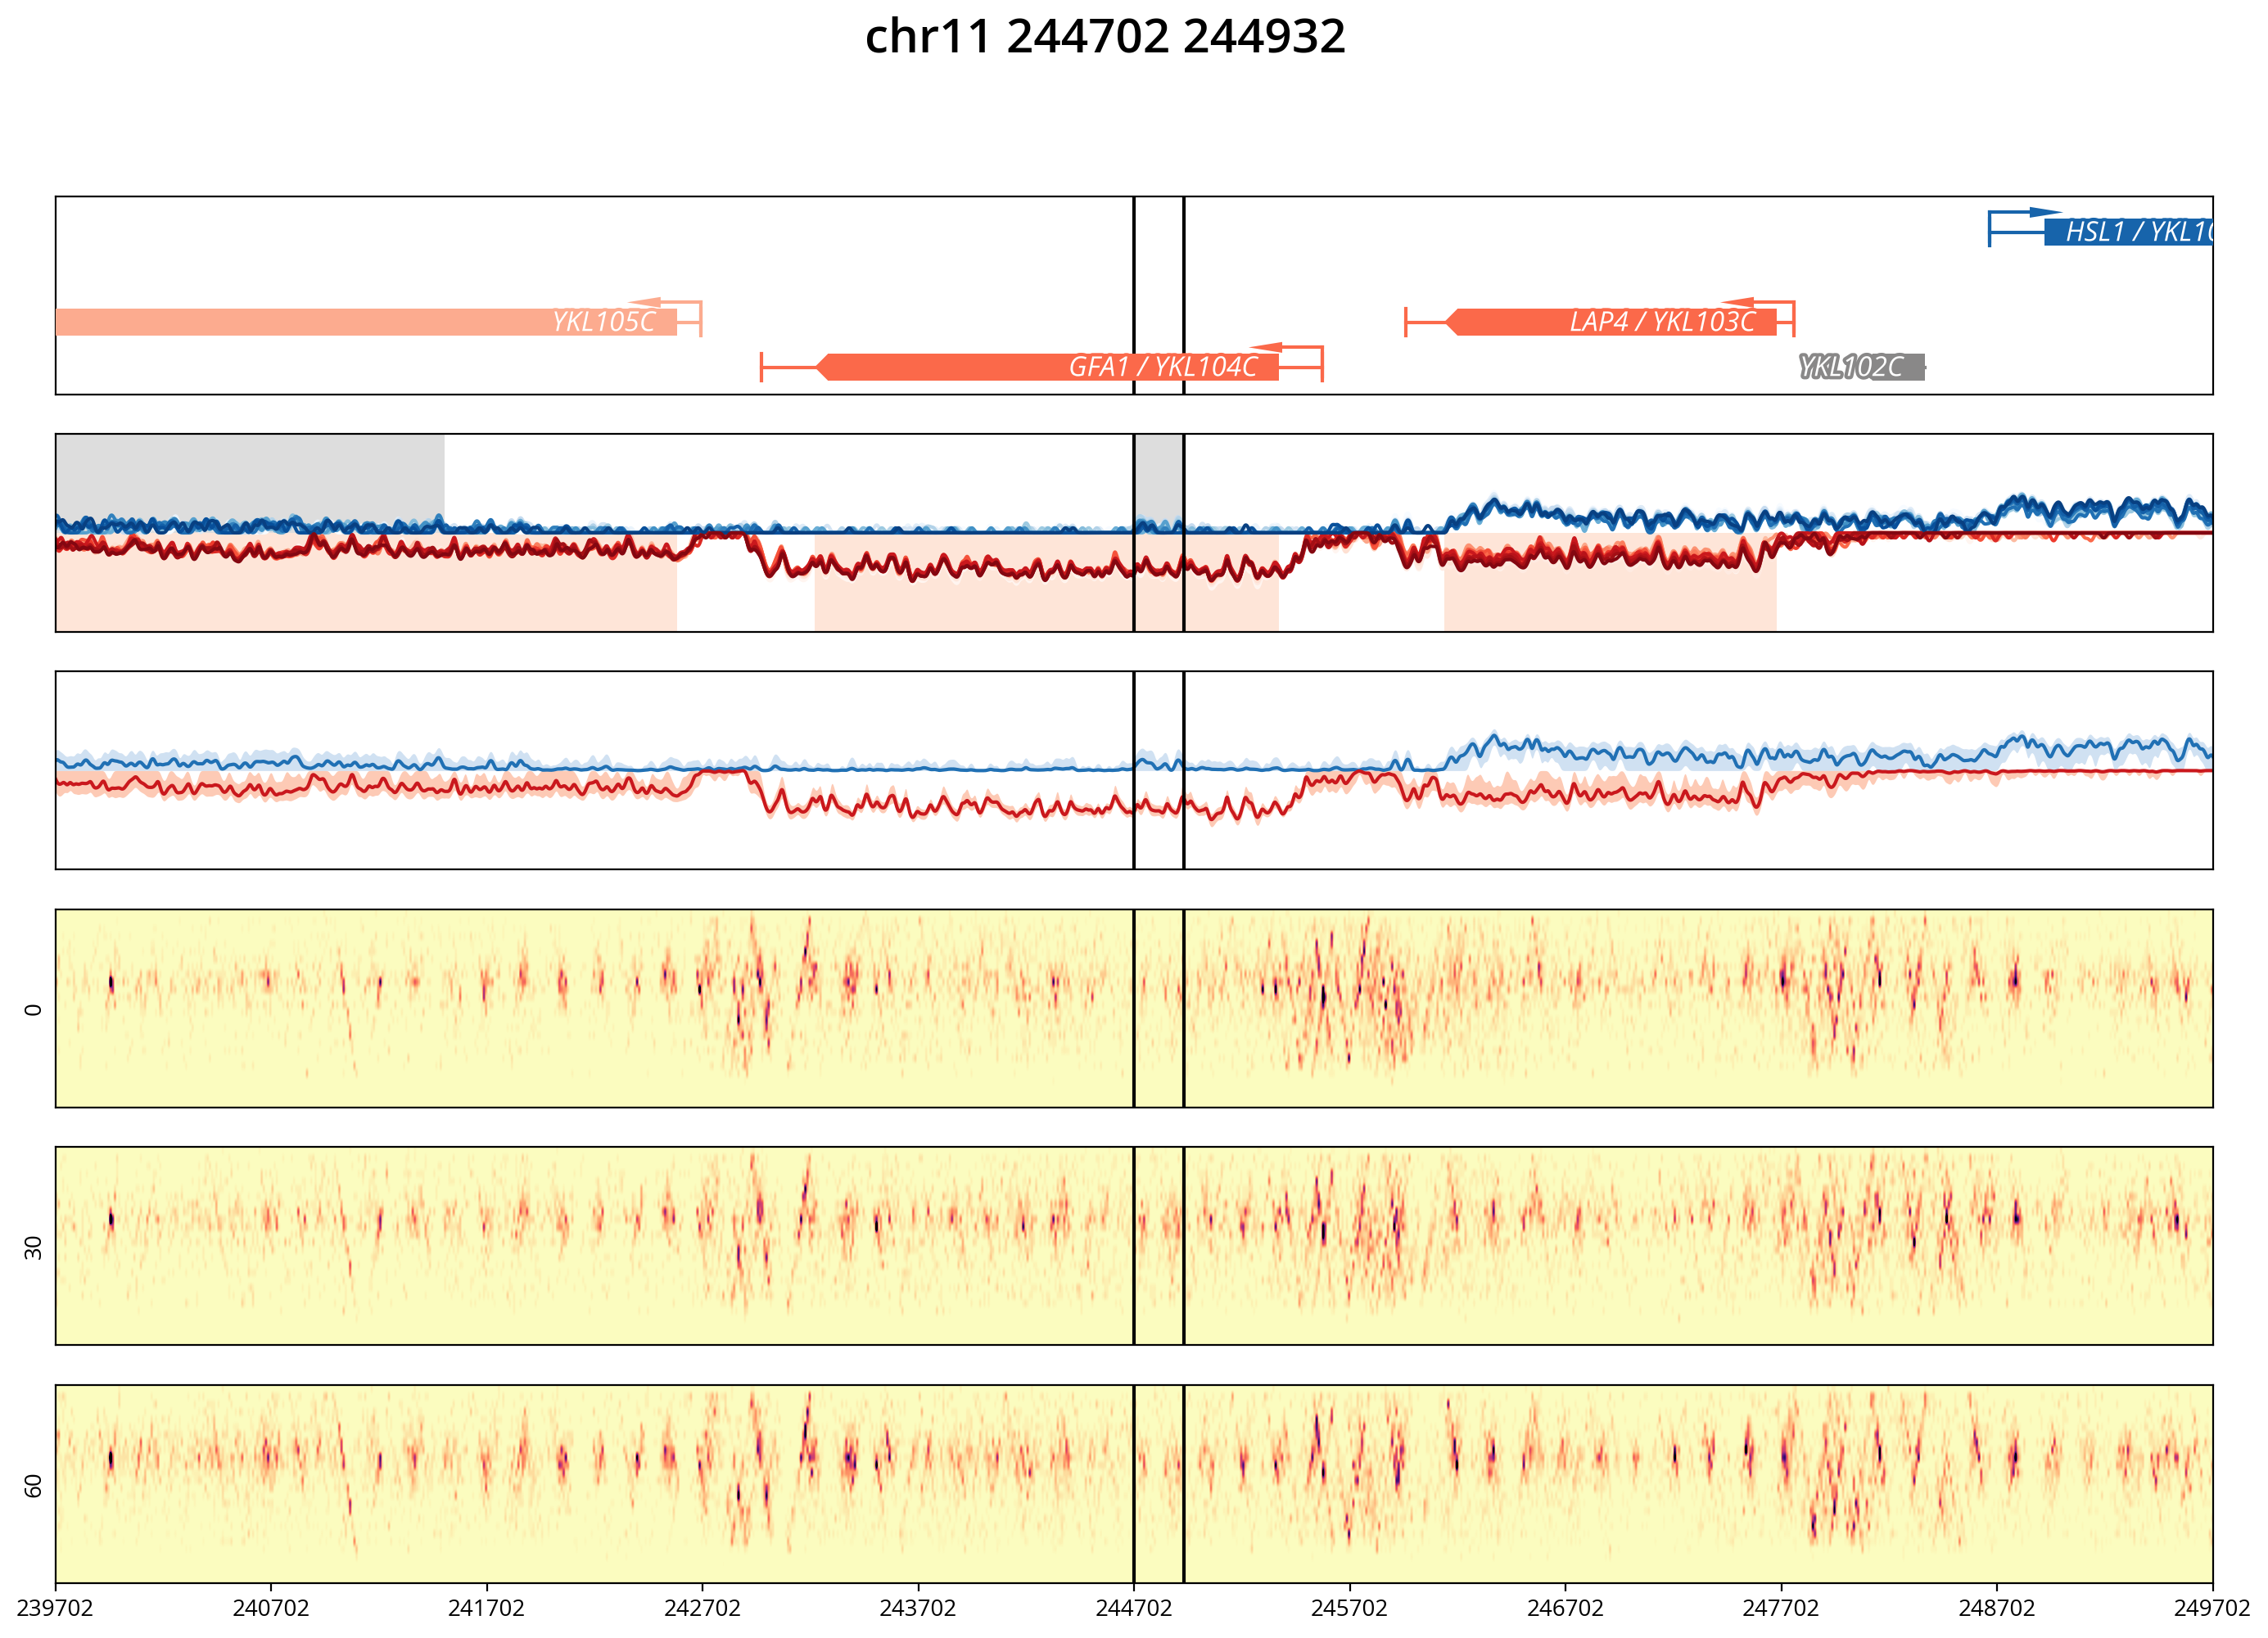

In [535]:
genic, nongenic = load_transcripts_sets(output_dir)

for i, transcript_name in enumerate(interesting_transcripts.index):
    tx_transcript = nongenic.loc[transcript_name]
    plot_tx_transcript_context(tx_transcript)
    plt.savefig(f'output/draft4_run/nongenic_analysis/locus_{i}_{transcript_name}.png', 
                dpi=200)
    #plt.close()
    break


In [835]:
from src.pileup_helpers import smooth_rna_curve
from src.transcript_boundary_caller import TranscriptBoundaryCaller
from src.sgd import get_chromosome_length

caller = TranscriptBoundaryCaller(output_directory=output_dir)

# Good example with MCD1
chrom = 1
span = 0, get_chromosome_length(chrom)
caller.set_chrom_span(chrom, span)


Creating directory: output/draft4_run//rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/draft4_run//rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 1
Intermediate directory: output/draft4_run//rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr1.h5, crick_rna_seq_pileup_rep1_chr1.h5
Shape: (16, 230218) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr1.h5, crick_rna_seq_pileup_rep2_chr1.h5
Shape: (14, 230218) (timepoints x positions)


In [838]:
caller.call_boundaries_both_strands()

In [867]:
from src.transcripts_dataset import TranscriptDatasetBuilder
tx_set_builder = TranscriptDatasetBuilder(output_dir)


In [868]:
tx_set_builder.load_transcripts(caller.chromosome_transcripts)

Loading transcripts from all chromosomes...
Loaded 64 gene-associated transcripts
Loaded 94 non-genic transcripts


In [874]:
tx_set_builder.update_sgd_tss_annotations()
tx_set_builder.define_nongenic_dataset()

Updating TSS annotations with RNA-seq calls...


In [875]:
tx_set_builder.updated_sgd_genes

,gene,chr,cat,start,stop,strand,classification,length,rna_called_TSS,Park_TSS,Park_PAS,TSS,PAS,promoter_start,promoter_end,gene_body_start,gene_body_end
orf_name,,,,,,,,,,,,,,,,,
YAL068C,PAU8,1,gene,1807,2169,-,Verified,362,NaN,NaN,NaN,2169,1807,2469,2169,2169,1669
YAL067W-A,None,1,gene,2480,2707,+,Uncharacterized,227,NaN,NaN,NaN,2480,2707,2180,2480,2480,2980
YAL067C,SEO1,1,gene,7235,9016,-,Verified,1781,NaN,NaN,NaN,9016,7235,9316,9016,9016,8516
YAL065C,None,1,gene,11565,11951,-,Uncharacterized,386,NaN,NaN,NaN,11951,11565,12251,11951,11951,11451
YAL064W-B,None,1,gene,12046,12426,+,Uncharacterized,380,NaN,NaN,NaN,12046,12426,11746,12046,12046,12546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YPR200C,ARR2,16,gene,939279,939671,-,Verified,392,NaN,939779.0,939195.0,939779,939195,940079,939779,939779,939279
YPR201W,ARR3,16,gene,939922,941136,+,Verified,1214,NaN,939858.0,NaN,939858,941136,939558,939858,939858,940358
YPR202W,None,16,gene,943032,943896,+,Uncharacterized,864,NaN,942768.0,NaN,942768,943896,942468,942768,942768,943268
